In [1]:
%cd fortran_src
!conda run -n simple_env \
    python3 -m numpy.f2py -c -m \
    wl_saving_conformations \
    wl_saving_conformations.f90 --opt='-O3'
%mkdir -p ../compiled_python_modules
%mv wl_saving_conformations*.so ../compiled_python_modules/
%cd ..


running build
running config_cc
INFO: unifing config_cc, config, build_clib, build_ext, build commands --compiler options
running config_fc
INFO: unifing config_fc, config, build_clib, build_ext, build commands --fcompiler options
running build_src
INFO: build_src
INFO: building extension "wl_saving_conformations" sources
INFO: f2py options: []
INFO: f2py:> /var/folders/n5/f496lkj93z1d5p8bbkfqkhtr0000gn/T/tmpfays3e5a/src.macosx-11.0-arm64-3.9/wl_saving_conformationsmodule.c
creating /var/folders/n5/f496lkj93z1d5p8bbkfqkhtr0000gn/T/tmpfays3e5a/src.macosx-11.0-arm64-3.9
Reading fortran codes...
	Reading file 'wl_saving_conformations.f90' (format:free)
Post-processing...
	Block: wl_saving_conformations
			Block: run_wl_low_energy
Applying post-processing hooks...
  character_backward_compatibility_hook
Post-processing (stage 2)...
Building modules...
    Building module "wl_saving_conformations"...
    Generating possibly empty wrappers"
    Maybe empty "wl_saving_conformations-f2pywrappe

In [2]:
import os 
import sys
module_path = "compiled_python_modules/"
sys.path.append(module_path)
import wl_saving_conformations

import numpy as np
import matplotlib.pyplot as plt

from general_python_module import *

### Load relevant variables

In [3]:
MJ_tab_6 = load_MJ_tab_6() # conventional order of amino acids given by num_to_letter_map variable
hamiltonian_walks_contacts=load_hamiltonian_walks_contacts()
hamiltonian_walks_max_abs_GE=load_hamiltonian_walks_max_abs_GE()
hamiltonian_walks_i1_i2=load_hamiltonian_walks_maGE_loop_i1_i2()
hamiltonian_walks_maGE_thread_is_N=load_hamiltonian_walks_maGE_thread_is_N()


In [4]:
i_struct=897
i_seq=0

print(f'The GE of structure {i_struct:} is {hamiltonian_walks_max_abs_GE[i_struct-1]:4.3f}.')

native_contacts=hamiltonian_walks_contacts[i_struct-1]
number_of_native_contacts=len(native_contacts)

print(f"Structure {i_struct:} is characterized by these contacts:")
print(f"{native_contacts[0]:} {native_contacts[1]:} ... {native_contacts[-2]:} {native_contacts[-1]:}")

numeric_msa=np.loadtxt(f"data/sequences_data/z_score_opt_sequences/struct_{i_struct:06d}/numeric_msa.txt",dtype=np.int32)
sequence=numeric_msa[0,:]
letters_sequence="".join([num_to_letter_map[v-1] for v in sequence])

print(f'The selected sequence is {letters_sequence:}.')



The GE of structure 897 is 0.700.
Structure 897 is characterized by these contacts:
[1 6] [ 1 22] ... [17 20] [18 27]
The selected sequence is WQKGDMMKGGDWWKAVKGTDYMLAMSG.


### Set the simulation variables
Here we set the variables of the actual refolding simulations. 
The

In [5]:
n_monomers=len(sequence)

n_flatness_checks=8
checks_flatness_every=100000


en_min=-17
en_max=17
bin_size=0.2
n_energy_bins=int((en_max-en_min)/(bin_size))+1

energy_bin_edges=np.linspace(-15,15+bin_size,n_energy_bins+1)-bin_size/2

energy_bin_centers=0.5*(energy_bin_edges[1:]+energy_bin_edges[:-1])
energy_bin_measures=energy_bin_edges[1:]-energy_bin_edges[:-1]
n_low_energy_structures=10
n_conformations_per_bin=100
save_conformation_every=100

prng_seed=np.random.randint(1,10000000)

flatness_trashold=0.9

max_n_steps=np.int64(1e9)


(low_energies,                     # 1. low_energies
 low_energies_contacts,            # 2. low_energies_contacts
 low_energies_n_contacts,          # 3. low_energies_n_contacts
 low_energies_n_native_contacts,   # 4. low_energies_n_native_contacts
 low_energy_bond_vectors,          # 5. low_energy_bond_vectors
 bin_has_been_visited,             # 6. bin_has_been_visited
 history_flat_histograms,          # 7. history_flat_histograms
 history_flat_ln_g_E,              # 8. history_flat_ln_g_E
 history_f_factor,                  # 9. history_f_factor
 saved_conformations,
 saved_conformations_contacts,
 saved_conformations_n_native_contacts
) = wl_saving_conformations.run_wl_low_energy(\
    n_flatness_checks=n_flatness_checks,
    checks_flatness_every=checks_flatness_every,
    prng_seed=prng_seed,
    n_monomers=n_monomers,
    sequence=sequence,
    interaction_matrix=MJ_tab_6,
    number_of_native_contacts=number_of_native_contacts,
    native_contacts=native_contacts,
    n_energy_bins=n_energy_bins,
    energy_bin_edges=energy_bin_edges,
    flatness_trashold=flatness_trashold,
    max_n_steps=max_n_steps,
    n_low_energy_structures=n_low_energy_structures,
    n_conformations_per_bin=n_conformations_per_bin,
    save_conformation_every=save_conformation_every)



(-14.24561403508772, 7.0)

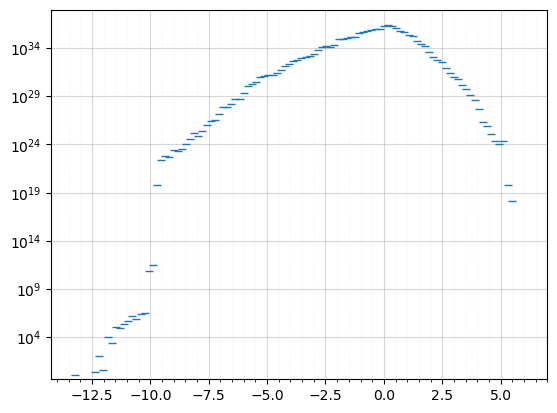

In [13]:
fig,ax=simple_plot_with_grid()

ind_flatness_check_pass=np.argwhere(history_flat_ln_g_E.sum(axis=0)>0)
final_ln_g_E=history_flat_ln_g_E[:,ind_flatness_check_pass[-1]]
final_ln_g_E=final_ln_g_E-final_ln_g_E[bin_has_been_visited.astype(np.bool_)][0]
final_g_E = np.exp(final_ln_g_E)
ax.plot(energy_bin_centers,final_g_E,'_')
ax.set_yscale('log')
ax.set_ylim([0.4,1e38])
ax.set_xlim([energy_bin_centers[bin_has_been_visited.astype(np.bool_)][0]-1.0,7])